### LAB ASSIGNMENT - 03
### CS23B1028 - R K LARIKA


#### Q1. Classify MNIST digits using CNN. 

1. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

2. Load Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


3. Plotting a few samples

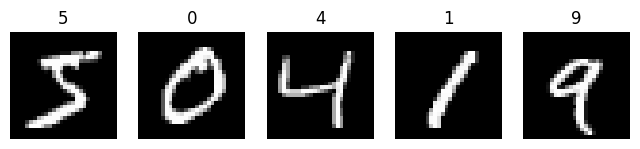

In [4]:
plt.figure(figsize=(8,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

4. Preprocessing

In [5]:
## Normalise
x_train = x_train / 255.0
x_test = x_test / 255.0


In [6]:
## Reshape for CNN (add channel)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [7]:
## One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


5. Build the CNN Model

In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\Users\Larika\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6. Compile the Model

In [9]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

7. Train the model

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Save best model based on validation accuracy
checkpoint = ModelCheckpoint("best_cnn_mnist.h5",
                             monitor="val_accuracy",
                             save_best_only=True,
                             mode="max",
                             verbose=1)

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.1,
                    callbacks=[checkpoint])

Epoch 1/10
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9945 - loss: 0.0181
Epoch 1: val_accuracy improved from -inf to 0.99033, saving model to best_cnn_mnist.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9945 - loss: 0.0181 - val_accuracy: 0.9903 - val_loss: 0.0346
Epoch 2/10
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9948 - loss: 0.0157
Epoch 2: val_accuracy did not improve from 0.99033
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9882 - val_loss: 0.0455
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9969 - loss: 0.0103
Epoch 3: val_accuracy did not improve from 0.99033
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9969 - loss: 0.0103 - val_accuracy: 0.9875 - val_loss: 0.0460
Epoch 4/10
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9961 - loss: 0.0112
Epoch 4: val_accuracy did not improve from 0.99033
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9961 - loss: 0.0112 - val_accuracy: 0.9892 - val_loss: 0.0482
Epoch 5/10
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9968 - loss: 0.0099
Epoch 5: val_accuracy impro

422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9968 - loss: 0.0099 - val_accuracy: 0.9907 - val_loss: 0.0346
Epoch 6/10
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9979 - loss: 0.0070
Epoch 6: val_accuracy improved from 0.99067 to 0.99167, saving model to best_cnn_mnist.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9979 - loss: 0.0070 - val_accuracy: 0.9917 - val_loss: 0.0361
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9982 - loss: 0.0058
Epoch 7: val_accuracy did not improve from 0.99167
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9880 - val_loss: 0.0497
Epoch 8/10
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9975 - loss: 0.0068
Epoch 8: val_accuracy did not improve from 0.99167
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9975 - loss: 0.0068 - val_accuracy: 0.9905 - val_loss: 0.0416
Epoch 9/10
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9985 - loss: 0.0048
Epoch 9: val_accuracy did not improve from 0.99167
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9908 - val_loss: 0.0494
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9989 - loss: 0.0033
Epoch 10: val_accuracy did

8. Load the Best Model

In [12]:
from tensorflow.keras.models import load_model

best_model = load_model("best_cnn_mnist.h5")

9. Test the Best Model on Test Dataset

In [13]:
test_loss, test_acc = best_model.evaluate(x_test, y_test)
print("Test Accuracy of Best CNN Model:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9879 - loss: 0.0418
Test Accuracy of Best CNN Model: 0.9907000064849854


10. Plotting Accuracy Curve

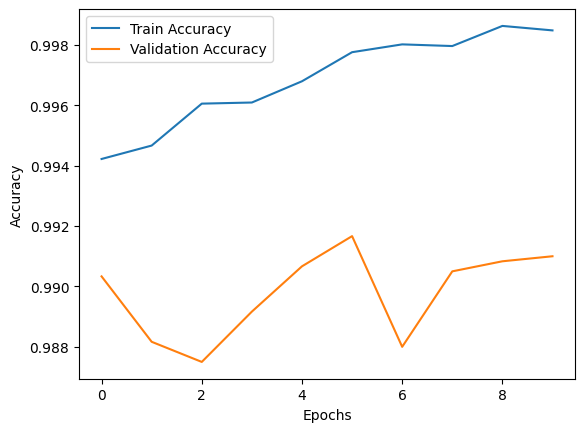

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Loss Curve

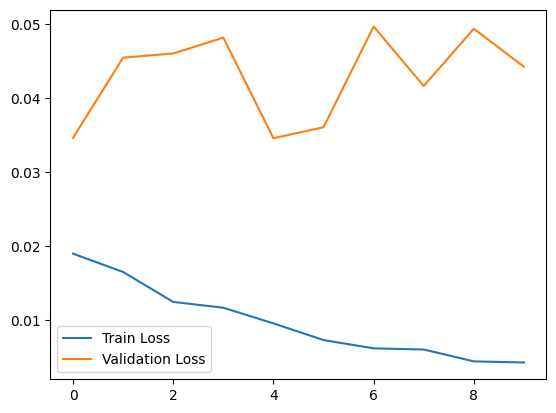

In [15]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


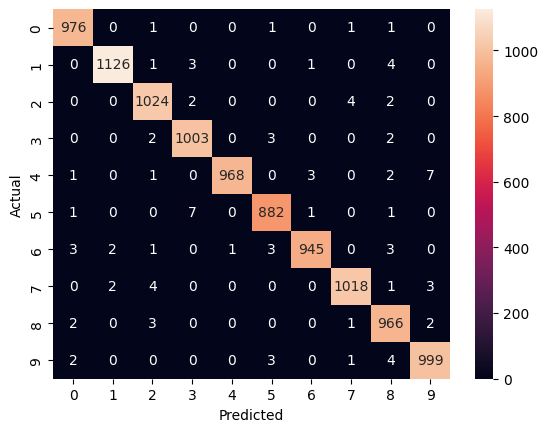

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = np.argmax(best_model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()